<a href="https://colab.research.google.com/github/NingyiXie418/Dog-Breed-Fetcher-Mini-Assignment/blob/main/%E2%80%9CCSC412_A1_Questions_ipynb%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- **Deadline**: Oct 5, at 23:59PM.
- **Submission**: You need to submit your solutions through Crowdmark, including all your *derivations*, *plots*, *your code*, and its *executed result*. **Please save the result as a single PDF file** (file name: `{your_student_id}.pdf`). Points will be deducted if we have a hard time reading your solutions or understanding the structure of your code.
- **Collaboration policy**: After attempting the problems on an individual basis, you may discuss and work together on the assignment with up to two classmates. However, **you must write your own code and write up your own solutions individually and explicitly name any collaborators** at the top of the homework.

In [34]:
1010030636

1010030636

# Q1 - Decision Theory

One successful use of probabilistic models is for building spam filters, which take in an email and take different actions depending on the likelihood that it’s spam.

Imagine you are running an email service. You have a well-calibrated spam classifier that tells you the probability that a particular email is spam: $p(spam|email)$. You have four options for what to do with each email: You can list it as important email, show it to the user, put it in the spam folder, or delete it entirely.

Depending on whether or not the email really is spam, the user will suffer a different amount  of wasted time for the different actions we can take, $L$(action, spam):

Action   | Spam        | Not spam
-------- | ----------- | -----------
Important| 12          | 0
Show     | 4           | 1
Folder   | 2           | 25
Delete   | 0           | 100

## Q1.1
[3pts] Plot the expected wasted user time for each of the four possible actions, as a function of the probability of spam: $p(spam|email)$.

[Hint: Your plot should have $p(\text{spam} \mid \text{email})$ on the x-axis and the expected loss on the y-axis, with four lines, one for each action.]

In [35]:
import numpy as np
import matplotlib.pyplot as plt

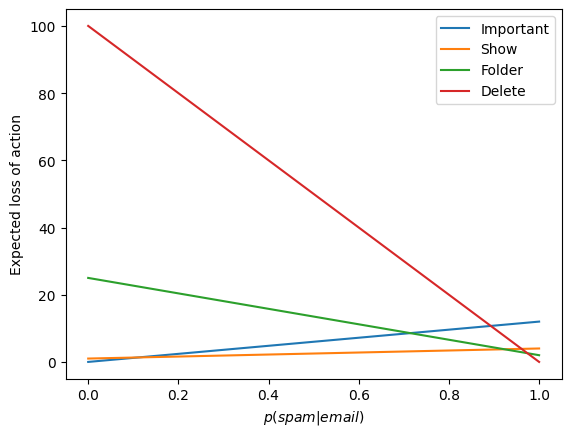

In [36]:
losses = [[12, 0],[4, 1], [2, 25],[0, 100]] # spam,not spam
actions_names = ['Important','Show', 'Folder', 'Delete']
num_actions = len(losses)
def expected_loss_of_action(prob_spam, action):
    # Return expected loss over a Bernoulli random variable
    # with mean prob_spam.
    # Losses are given by the table above.
    loss_spam = losses[action][0]
    loss_not_spam = losses[action][1]
    return loss_spam * prob_spam + loss_not_spam * (1 - prob_spam)

prob_range = np.linspace(0., 1., num=600)

# Make plot
for action in range(num_actions):
    plt.plot(prob_range, expected_loss_of_action(prob_range, action)
    , label=actions_names[action])

plt.xlabel('$p(spam|email)$')
plt.ylabel('Expected loss of action')
plt.legend()
plt.show()

## Q1.2
[2pts] Write a function that computes the optimal action given the probability of spam.

In [37]:
def optimal_action(prob_spam):
    #TODO: return best action given the probability of spam.
    #Hint: np.argmin might be helpful.
    expected_loss = [
        expected_loss_of_action(prob_spam, action)
        for action in range(num_actions)
        ]
    return np.argmin(expected_loss)

## Q1.3
[4pts] Plot the expected loss of the optimal action as a function of the probability of spam.


Color the line according to the optimal action for that probability of spam.


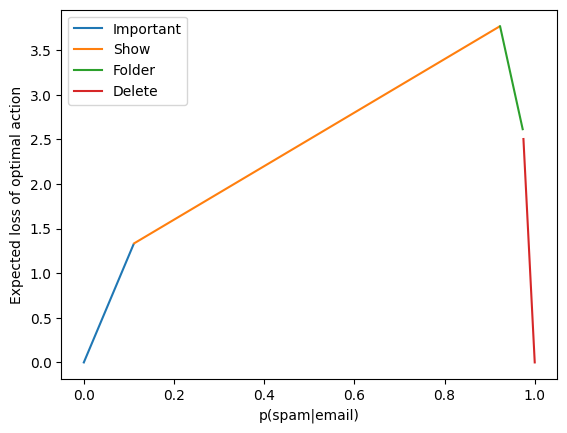

In [38]:
prob_range = np.linspace(0., 1., num=600)
optimal_losses = []
optimal_actions = []
for p in prob_range:
    # Compute the optimal action and its expected loss for
    # probability of spam given by p.
    action = optimal_action(p)
    loss = expected_loss_of_action(p, action)
    optimal_losses.append(loss)
    optimal_actions.append(action)

plt.xlabel('p(spam|email)')
plt.ylabel('Expected loss of optimal action')
for action in range(num_actions):
    action_losses = np.where(
        np.array(optimal_actions) == action,
        optimal_losses,
        np.nan
    )
    plt.plot(prob_range, action_losses
             , label=actions_names[action])
plt.legend()
plt.show()

## Q1.4
[4pts] For exactly which range of the probabilities of an email being spam should we delete an email?

Find the exact answer by hand using algebra.

Let
$$
p = p(\mathrm{spam}\mid\mathrm{email}), \qquad 0\le p\le 1.
$$
Then
$$
p(\mathrm{spam})=p,
\qquad
p(\mathrm{not\ spam})=1-p.
$$
For any action $a$, its expected loss is
$$
\mathbb{E}[L(a)]
=
p\,L(a,\mathrm{spam})
+
(1-p)L(a,\mathrm{not\ spam}).
$$
Therefore, the expected losses of the four actions are
$$
L_I
=
12p+0(1-p)
=
12p,
$$
$$
L_S
=
4p+1(1-p)
=
1+3p,
$$
$$
L_F
=
2p+25(1-p)
=
25-23p,
$$
and
$$
L_D
=
0p+100(1-p)
=
100-100p.
$$
For Delete to be an optimal action, its expected loss must be no greater
than the expected loss of every other action.
Comparing Delete with Important,
$$
100-100p\le 12p
$$
gives
$$
p\ge \frac{25}{28}.
$$
Comparing Delete with Show,
$$
100-100p\le 1+3p
$$
gives
$$
p\ge \frac{99}{103}.
$$
Comparing Delete with Folder,
$$
100-100p\le 25-23p
$$
gives
$$
p\ge \frac{75}{77}.
$$

All three inequalities must hold simultaneously. Since
$$
\frac{75}{77}
>
\frac{99}{103}
>
\frac{25}{28},
$$
and $p\le1$, Delete is an optimal action exactly when
$$
{
\frac{75}{77}\le p\le1
}.
$$
At the boundary
$$
p=\frac{75}{77},
$$
Delete and Folder have the same expected loss, so both actions are
optimal. Therefore, Delete is uniquely optimal when
$$
{
\frac{75}{77}<p\le1
}.
$$

# Q2 - Naïve Bayes, A Generative Model

![](https://github.com/zalandoresearch/fashion-mnist/blob/master/doc/img/fashion-mnist-sprite.png?raw=true)


In this question, we'll fit a Naïve Bayes model to the fashion MNIST dataset, and use this model for making predictions and generating new images from the same distribution. MNIST is a dataset of 28x28 black-and-white images of items of clothing. We represent each image by a vector $x^{(i)} \in \{0,1\}^{784}$, where 0 and 1 represent white and black pixels respectively. Each class label $c^{(i)}$ is a different item of clothing, which in the code is represented by a 10-dimensional one-hot vector.

The Naïve Bayes model parameterized by $\theta$ and $\pi$ defines the following joint probability of $x$ and $c$,
$$p(x,c|\theta,\pi) = p(c|\pi)p(x|c,\theta) = p(c|\pi)\prod_{j=1}^{784}p(x_j|c,\theta),$$
where $x_j | c,\theta \sim \operatorname{Bernoulli}(\theta_{jc})$ or in other words $p(x_j | c,\theta) = \theta_{jc}^{x_j}(1-\theta_{jc})^{1-x_j}$, and $c|\pi$ follows a simple categorical distribution, i.e. $p(c|\pi) = \pi_c$.

We begin by learning the parameters $\theta$ and $\pi$. The following code will download and prepare the training and test sets.

In [39]:
import numpy as np
import os
import gzip
import struct
import array
import matplotlib.pyplot as plt
import matplotlib.image
from urllib.request import urlretrieve

def download(url, filename):
    if not os.path.exists('data'):
        os.makedirs('data')
    out_file = os.path.join('data', filename)
    if not os.path.isfile(out_file):
        urlretrieve(url, out_file)


def fashion_mnist():
    base_url = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/'

    def parse_labels(filename):
        with gzip.open(filename, 'rb') as fh:
            magic, num_data = struct.unpack(">II", fh.read(8))
            return np.array(array.array("B", fh.read()), dtype=np.uint8)

    def parse_images(filename):
        with gzip.open(filename, 'rb') as fh:
            magic, num_data, rows, cols = struct.unpack(">IIII", fh.read(16))
            return np.array(
                array.array("B", fh.read())
                , dtype=np.uint8).reshape(num_data, rows, cols)

    for filename in ['train-images-idx3-ubyte.gz',
                     'train-labels-idx1-ubyte.gz',
                     't10k-images-idx3-ubyte.gz',
                     't10k-labels-idx1-ubyte.gz']:
        download(base_url + filename, filename)

    train_images = parse_images('data/train-images-idx3-ubyte.gz')
    train_labels = parse_labels('data/train-labels-idx1-ubyte.gz')
    test_images = parse_images('data/t10k-images-idx3-ubyte.gz')
    test_labels = parse_labels('data/t10k-labels-idx1-ubyte.gz')

    # Remove the data point that cause log(0)
    remove = (14926, 20348, 36487, 45128, 50945, 51163, 55023)
    train_images = np.delete(train_images,remove, axis=0)
    train_labels = np.delete(train_labels, remove, axis=0)
    return train_images, train_labels, test_images[:1000], test_labels[:1000]


def load_fashion_mnist():
    partial_flatten = lambda x: np.reshape(x, (
        x.shape[0], np.prod(x.shape[1:])))
    one_hot = lambda x, k: np.array(
        x[:, None] == np.arange(k)[None, :], dtype=int)
    train_images, train_labels, test_images, test_labels =  fashion_mnist()
    train_images = (partial_flatten(train_images) / 255.0 > .5).astype(float)
    assert train_images.dtype == np.float64
    test_images = (partial_flatten(test_images) / 255.0 > .5).astype(float)
    train_labels = one_hot(train_labels, 10)
    test_labels = one_hot(test_labels, 10)
    N_data = train_images.shape[0]

    return N_data, train_images, train_labels, test_images, test_labels

## Q2.1
[2pts] Derive the expression for the Maximum Likelihood Estimator (MLE) of $\theta$ and $\pi$.

For $N$ training examples, let the training set be $\{(x^{(i)},c^{(i)})\}_{i=1}^{N}$, where
$x^{(i)} \in \{0,1\}^{784}$ and $c^{(i)}$ is a one-hot class vector.

Define
$$
c_c^{(i)} =
\begin{cases}
1, & \text{if example } i \text{ belongs to class } c,\\
0, & \text{otherwise}.
\end{cases}
$$

Let
$$
N_c = \sum_{i=1}^{N} c_c^{(i)}
$$
be the number of training examples belonging to class $c$.
The log-likelihood is
$$
\ell(\theta,\pi)
=
\sum_{i=1}^{N}\sum_c c_c^{(i)}
\left[
\log \pi_c
+
\sum_{j=1}^{784}
\left(
x_j^{(i)}\log\theta_{jc}
+
(1-x_j^{(i)})\log(1-\theta_{jc})
\right)
\right].
$$
For $\theta_{jc}$,

$$
\frac{\partial \ell}{\partial \theta_{jc}}
=
\sum_{i=1}^{N} c_c^{(i)}
\left(
\frac{x_j^{(i)}}{\theta_{jc}}
-
\frac{1-x_j^{(i)}}{1-\theta_{jc}}
\right)
=0.
$$

Solving for $\theta_{jc}$ gives
$$
\hat{\theta}_{jc}
=
\frac{\sum_{i=1}^{N} c_c^{(i)}x_j^{(i)}}
{\sum_{i=1}^{N} c_c^{(i)}}.
$$
Thus, $\hat{\theta}_{jc}$ is the fraction of training examples in class $c$ for which pixel $j$ is equal to 1.
For $\pi_c$, maximizing
$$
\sum_{i=1}^{N}\sum_c c_c^{(i)}\log \pi_c
$$
subject to
$$
\sum_c \pi_c = 1
$$
Using a Lagrange multiplier for the constraint $\sum_c\pi_c=1$,
$$
\mathcal{L}
=
\sum_c N_c\log\pi_c
+
\lambda\left(\sum_c\pi_c-1\right).
$$

Setting the derivative with respect to $\pi_c$ to zero,
$$
\frac{N_c}{\pi_c}+\lambda=0.
$$
Using $\sum_c\pi_c=1$ gives $\lambda=-N$, and therefore
$$
\hat{\pi}_c=\frac{N_c}{N}.
$$
Thus, $\hat{\pi}_c$ is the fraction of training examples belonging to class $c$.



## Q2.2
[4pts] Using the MLE for this data, many entries of $\theta$ will be estimated to be 0, which seems extreme. So we look for another estimation method.

Assume the prior distribution of $\theta$ is such that the entries are i.i.d. and drawn from $\operatorname{Beta}(4,3)$. Derive the Maximum A Posteriori (MAP) estimator for $\theta$ (it has a simple final form). You can return the MLE for $\pi$ in your implementation. From now on, we will work with this estimator.

Let
$$
S_{jc} = \sum_{i=1}^{N} c_c^{(i)}x_j^{(i)}
$$
be the number of examples in class $c$ for which pixel $j$ is equal to 1,
and let
$$
N_c = \sum_{i=1}^{N} c_c^{(i)}.
$$
For a fixed $\theta_{jc}$, the likelihood is proportional to
$$
p(D\mid\theta_{jc})
\propto
\theta_{jc}^{S_{jc}}
(1-\theta_{jc})^{N_c-S_{jc}}.
$$
The prior is
$$
\theta_{jc}\sim\mathrm{Beta}(4,3),
$$

For a Beta$(\alpha,\beta)$ distribution, the density is proportional to
$$
p(\theta)\propto \theta^{\alpha-1}(1-\theta)^{\beta-1}.
$$

Therefore, for the Beta$(4,3)$ prior,
$$
p(\theta_{jc})
\propto
\theta_{jc}^{3}(1-\theta_{jc})^{2}.
$$

Thus, the prior contributes $3$ pseudo-counts for $x_j=1$ and $2$ pseudo-counts for $x_j=0$. Hence the numerator of the MAP estimator gains $3$, while the denominator gains
$$
3+2=5.
$$

Therefore, the posterior is proportional to
$$
p(\theta_{jc}\mid D)
\propto
\theta_{jc}^{S_{jc}+3}
(1-\theta_{jc})^{N_c-S_{jc}+2}.
$$

The log posterior, ignoring constants independent of $\theta_{jc}$, is
$$
\ell_{MAP}
=
(S_{jc}+3)\log\theta_{jc}
+
(N_c-S_{jc}+2)\log(1-\theta_{jc}).
$$

Taking the derivative,
$$
\frac{\partial \ell_{MAP}}{\partial\theta_{jc}}
=
\frac{S_{jc}+3}{\theta_{jc}}
-
\frac{N_c-S_{jc}+2}{1-\theta_{jc}}.
$$

Setting it equal to zero gives
$$
(S_{jc}+3)(1-\theta_{jc})
=
(N_c-S_{jc}+2)\theta_{jc},
$$

and therefore
$$
\hat{\theta}_{jc}^{MAP}
=
\frac{S_{jc}+3}{N_c+5}
=
\frac{
\sum_{i=1}^{N} c_c^{(i)}x_j^{(i)}+3
}{
\sum_{i=1}^{N} c_c^{(i)}+5
}.
$$

For $\pi$, we use the MLE from Q2.1:
$$
\hat{\pi}_c
=
\frac{N_c}{N}.
$$


In [40]:
def train_map_estimator(train_images, train_labels):
    """ Inputs: train_images (N_samples x N_features),
    train_labels (N_samples x N_classes)
        Returns the MAP estimator theta_est (N_features x N_classes)
        and the MLE
        estimator pi_est (N_classes)"""

    # YOU NEED TO WRITE THIS PART
    N = train_images.shape[0]
    class_counts = np.sum(train_labels, axis=0)
    # num of training ex
    pixel_counts = train_images.T @ train_labels
    theta_est = (pixel_counts + 3) / (class_counts + 5 ) # MAP
    pi_est = class_counts / N # MLE
    return theta_est, pi_est

## Q2.3
[5pts] Derive an expression for the class log-likelihood $\log p(c|x,\theta,\pi)$ for a single image. Then, complete the implementation of the following functions. Recall that our prediction rule is to choose the class that maximizes the above log-likelihood, and accuracy is defined as the fraction of samples that are correctly predicted.

Report the average log-likelihood $\frac{1}{N}\sum_{i=1}^{N}\log p(c^{(i)}|x^{(i)},\hat{\theta},\hat{\pi})$ (where $N$ is the number of samples) on the training test, as well the training and test errors.

For a single image $x$, the Naive Bayes joint distribution is
$$
p(x,c\mid\theta,\pi)
=
\pi_c
\prod_{j=1}^{784}
\theta_{jc}^{x_j}
(1-\theta_{jc})^{1-x_j}.
$$

By Bayes' rule,
$$
p(c\mid x,\theta,\pi)
=
\frac{p(x,c\mid\theta,\pi)}
{p(x\mid\theta,\pi)}
=
\frac{p(x,c\mid\theta,\pi)}
{\sum_{c'}p(x,c'\mid\theta,\pi)}.
$$

Substituting the Naive Bayes joint distribution gives
$$
p(c\mid x,\theta,\pi)
=
\frac{
\pi_c
\prod_{j=1}^{784}
\theta_{jc}^{x_j}
(1-\theta_{jc})^{1-x_j}
}{
\sum_{c'}
\pi_{c'}
\prod_{j=1}^{784}
\theta_{jc'}^{x_j}
(1-\theta_{jc'})^{1-x_j}
}.
$$

Taking the logarithm,
$$
\log p(c\mid x,\theta,\pi)
=
\log \pi_c
+
\sum_{j=1}^{784}
\left[
x_j\log\theta_{jc}
+
(1-x_j)\log(1-\theta_{jc})
\right]
-
\log
\left(
\sum_{c'}
\pi_{c'}
\prod_{j=1}^{784}
\theta_{jc'}^{x_j}
(1-\theta_{jc'})^{1-x_j}
\right).
$$

Define the unnormalized class log-score, which is the log joint probability,
$$
s_c(x)
=
\log p(x,c\mid\theta,\pi)
=
\log\pi_c
+
\sum_{j=1}^{784}
\left[
x_j\log\theta_{jc}
+
(1-x_j)\log(1-\theta_{jc})
\right].
$$
For brevity, we write $s_c(x)$ when $\theta$ and $\pi$ are fixed.

Then
$$
p(c\mid x,\theta,\pi)
=
\frac{\exp(s_c(x))}
{\sum_{c'}\exp(s_{c'}(x))}.
$$

Since $s_c(x)=\log p(x,c\mid\theta,\pi)$, we have
$\exp(s_c(x))=p(x,c\mid\theta,\pi)$. The denominator sums the joint
probabilities over all possible classes, so it normalizes them into the
posterior distribution over $c$.

Therefore,
$$
\log p(c\mid x,\theta,\pi)
=
s_c(x)
-
\log\sum_{c'}\exp(s_{c'}(x)).
$$

For a fixed image $x$, the normalization term
$$
\log\sum_{c'}\exp(s_{c'}(x))
$$
is the same for every candidate class $c$. Therefore, maximizing the
posterior log-probability is equivalent to maximizing the class log-score
$s_c(x)$.

The predicted class is therefore
$$
\hat{c}
=
\arg\max_c \log p(c\mid x,\theta,\pi)
=
\arg\max_c s_c(x).
$$

The classification accuracy is the fraction of samples whose predicted
class equals the true class.


In [41]:
def log_likelihood(images, theta, pi):
    """ Inputs: images (N_samples x N_features), theta, pi
        Returns the matrix 'log_like' of loglikehoods over the input
        images where
        log_like[i,c] = log p (c |x^(i), theta, pi) using the estimators
        theta and pi.
        log_like is a matrix of (N_samples x N_classes)
    Note that log likelihood is not only for c^(i), it is
    for all possible c's."""

    # YOU NEED TO WRITE THIS PART
    log_joint = (images @np.log(theta)
                 + (1-images) @ np.log(1-theta)) + np.log(pi)
    max_log_joint = np.max(log_joint, axis=1, keepdims=True)
    log_normalizer = (max_log_joint
                      + np.log(
                          np.sum(
                              np.exp(log_joint - max_log_joint),
                              axis=1, keepdims=True)))
    log_like = log_joint - log_normalizer
    return log_like


def accuracy(log_like, labels):
    """ Inputs: matrix of log likelihoods and
    1-of-K labels (N_samples x N_classes)
    Returns the accuracy based on predictions from log likelihood values"""

    # YOU NEED TO WRITE THIS PART
    predictions = np.argmax(log_like, axis=1)
    true_labels = np.argmax(labels, axis=1)
    return np.mean(predictions == true_labels)


(
    N_data,
    train_images,
    train_labels,
    test_images,
    test_labels,
) = load_fashion_mnist()
theta_est, pi_est = train_map_estimator(train_images, train_labels)

loglike_train = log_likelihood(train_images, theta_est, pi_est)
avg_loglike = np.sum(loglike_train * train_labels) / N_data
train_accuracy = accuracy(loglike_train, train_labels)
loglike_test = log_likelihood(test_images, theta_est, pi_est)
test_accuracy = accuracy(loglike_test, test_labels)

train_error = 1 - train_accuracy
test_error = 1 - test_accuracy

print(f"Average log-likelihood for MAP is {avg_loglike:.3f}")
print(f"Training accuracy for MAP is {train_accuracy:.3f}")
print(f"Test accuracy for MAP is {test_accuracy:.3f}")
print(f"Training error for MAP is {train_error:.3f}")
print(f"Test error for MAP is {test_error:.3f}")

Average log-likelihood for MAP is -34.449
Training accuracy for MAP is 0.650
Test accuracy for MAP is 0.637
Training error for MAP is 0.350
Test error for MAP is 0.363


## Q2.4
[2pts] Given this model's assumptions, is it always true that any two pixels $x_i$ and $x_j$ with $i \neq j$ are indenepdent given $c$? How about after marginalizing over $c$? Explain your answer.

Yes.
Under the Naive Bayes assumption,
$$
p(x\mid c,\theta)
=
\prod_{j=1}^{784} p(x_j\mid c,\theta).
$$
Therefore, the pixels are conditionally independent given the class $c$. For any $i \neq j$,
$$
p(x_i,x_j\mid c,\theta)
=
p(x_i\mid c,\theta)p(x_j\mid c,\theta),
$$

so

$$
x_i \perp x_j \mid c.
$$

However, after marginalizing over $c$, the pixels are not necessarily
independent. We have
$$
p(x_i,x_j\mid\theta,\pi)
=
\sum_c
p(c\mid\pi)
p(x_i\mid c,\theta)
p(x_j\mid c,\theta).
$$
whereas marginal independence would require
$$
p(x_i,x_j\mid\theta,\pi)
=
p(x_i\mid\theta,\pi)p(x_j\mid\theta,\pi),
$$
where
$$
p(x_i\mid\theta,\pi)
=
\sum_c p(c\mid\pi)p(x_i\mid c,\theta),
$$

and similarly for $x_j$.
These two expressions are not equal in general. Therefore, $x_i$ and
$x_j$ are conditionally independent given $c$, but are generally
dependent after marginalizing over $c$. The class $c$ acts as a common
cause of the pixels.


## Q2.5
[4pts] Since we have a generative model for our data, we can do more than just prediction. Randomly sample and plot 12 images from the learned distribution using the MAP estimates. (Hint: You first need to sample the class $c$, and then sample pixels conditioned on $c$.)

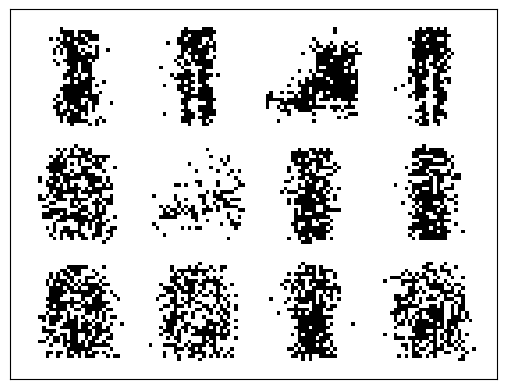

In [42]:
def image_sampler(theta, pi, num_images):
    """ Inputs: parameters theta and pi, and number of images to sample
    Returns the sampled images (N_images x N_features)"""

    # YOU NEED TO WRITE THIS PART
    num_features, num_classes = theta.shape
    sampled_images = np.zeros((num_images, num_features))
    for i in range(num_images):
      c = np.random.choice(num_classes, p=pi)
      sampled_images[i, :] = np.random.binomial(1, theta[:, c])
    return sampled_images


def plot_images(images, ims_per_row=5, padding=5, image_dimensions=(28, 28),
                cmap=matplotlib.cm.binary, vmin=0., vmax=1.):
    """Images should be a (N_images x pixels) matrix."""
    fig = plt.figure(1)
    fig.clf()
    ax = fig.add_subplot(111)

    N_images = images.shape[0]
    N_rows = np.int32(np.ceil(float(N_images) / ims_per_row))
    pad_value = vmin
    concat_images = np.full(
    (
        (image_dimensions[0] + padding) * N_rows + padding,
        (image_dimensions[1] + padding) * ims_per_row + padding,
    ),
    pad_value,
)
    for i in range(N_images):
        cur_image = np.reshape(images[i, :], image_dimensions)
        row_ix = i // ims_per_row
        col_ix = i % ims_per_row
        row_start = padding + (padding + image_dimensions[0]) * row_ix
        col_start = padding + (padding + image_dimensions[1]) * col_ix
        concat_images[row_start: row_start + image_dimensions[0],
                      col_start: col_start + image_dimensions[1]] = cur_image
        cax = ax.matshow(concat_images, cmap=cmap, vmin=vmin, vmax=vmax)
        plt.xticks(np.array([]))
        plt.yticks(np.array([]))

    plt.plot()


sampled_images = image_sampler(theta_est, pi_est, 12)
plot_images(sampled_images, ims_per_row=4)

## Q2.6
[4pts] One of the advantages of generative models is that they can handle missing data, or be used to answer different sorts of questions about the model. Assume we have only observed some pixels of the image. Let $x_E = \{x_p : \text{pixel $p$ is observed}\}$. Derive an expression for $p(x_j|x_E,\theta,\pi)$, the conditional probability of an unobserved pixel $j$ given the observed pixels and distribution parameters. (Hint: You have to marginalize over $c$.)

Let $E$ denote the set of observed pixel indices, and let $j\notin E$ be an
unobserved pixel. We marginalize over the unknown class $c$:
$$
p(x_j\mid x_E,\theta,\pi)
=
\sum_c p(x_j,c\mid x_E,\theta,\pi).
$$

Using the product rule,
$$
p(x_j\mid x_E,\theta,\pi)
=
\sum_c
p(x_j\mid c,x_E,\theta,\pi)
p(c\mid x_E,\theta,\pi).
$$

Under the Naive Bayes assumption, the pixels are conditionally independent
given the class $c$. Since $j\notin E$,
$$
p(x_j\mid c,x_E,\theta,\pi)
=
p(x_j\mid c,\theta).
$$

Therefore,
$$
p(x_j\mid x_E,\theta,\pi)
=
\sum_c
p(x_j\mid c,\theta)
p(c\mid x_E,\theta,\pi).
$$

By Bayes' rule,
$$
p(c\mid x_E,\theta,\pi)
=
\frac{
p(c\mid\pi)p(x_E\mid c,\theta)
}{
\sum_{c'}
p(c'\mid\pi)p(x_E\mid c',\theta)
}.
$$

Since the observed pixels are conditionally independent given $c$,
$$
p(x_E\mid c,\theta)
=
\prod_{p\in E}
\theta_{pc}^{x_p}
(1-\theta_{pc})^{1-x_p}.
$$

Thus,
$$
p(c\mid x_E,\theta,\pi)
=
\frac{
\pi_c
\prod_{p\in E}
\theta_{pc}^{x_p}
(1-\theta_{pc})^{1-x_p}
}{
\sum_{c'}
\pi_{c'}
\prod_{p\in E}
\theta_{pc'}^{x_p}
(1-\theta_{pc'})^{1-x_p}
}.
$$

Since
$$
p(x_j\mid c,\theta)
=
\theta_{jc}^{x_j}(1-\theta_{jc})^{1-x_j},
$$
the desired conditional distribution is
$$
p(x_j\mid x_E,\theta,\pi)
=
\sum_c
\theta_{jc}^{x_j}(1-\theta_{jc})^{1-x_j}
\frac{
\pi_c
\prod_{p\in E}
\theta_{pc}^{x_p}
(1-\theta_{pc})^{1-x_p}
}{
\sum_{c'}
\pi_{c'}
\prod_{p\in E}
\theta_{pc'}^{x_p}
(1-\theta_{pc'})^{1-x_p}
}.
$$

In particular, since $x_j$ is binary,
$$
p(x_j=1\mid x_E,\theta,\pi)
=
\sum_c
\theta_{jc}\,
p(c\mid x_E,\theta,\pi).
$$


## Q2.7
[4pts] We assume that only 45% of the pixels are observed. For the first 20 images in the training set, plot the images when the unobserved pixels are left as white, as well as the same images when the unobserved pixels are filled with the marginal probability of the pixel being 1 given the observed pixels, i.e. the value of the unobserved pixel $j$ is $p(x_j = 1|x_E,\theta,\pi)$.

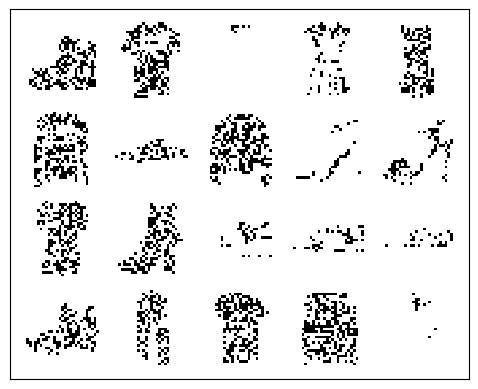

In [43]:
def probabilistic_imputer(theta, pi, original_images, is_observed):
    """Inputs: parameters theta and pi,
    original_images (N_images x N_features),
        and is_observed which has the same shape as original_images,
        with a value
        1. in every observed entry and 0. in every unobserved entry.
    Returns the new images where unobserved pixels are replaced by their
    conditional probability"""

    # YOU NEED TO WRITE THIS PART
    log_scores = (
        (original_images * is_observed) @ np.log(theta)
                  + ((1 - original_images) * is_observed) @ np.log(1 - theta)
                  + np.log(pi)
     ) # compute class log scores
    max_log_scores = np.max(log_scores, axis=1, keepdims=True)
    class_probs = np.exp(log_scores - max_log_scores)
    class_probs = class_probs / np.sum(class_probs, axis=1, keepdims=True)
    pixel_probs = class_probs @ theta.T
    imputed_images = (original_images * is_observed
                      + pixel_probs * (1 - is_observed))
    return imputed_images



num_features = train_images.shape[1]
is_observed = np.random.binomial(1, p=0.45, size=(20, num_features))
plot_images(train_images[:20] * is_observed)

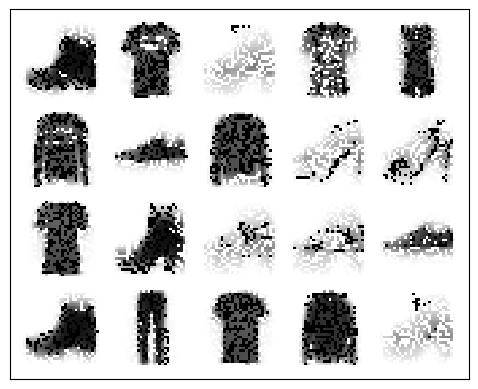

In [44]:
imputed_images = probabilistic_imputer(theta_est, pi_est, train_images[:20], is_observed)
plot_images(imputed_images)

# Q3 - Bayes Ball Algorithm

## Q3.1
[8pts]

Consider the following directed acyclic graph. Use the Bayes ball algorithm to compute all the nodes that are independent of $C$ given

i: $\{B, D\}$,

ii: $\{H\}$.

![picture](https://drive.google.com/uc?export=view&id=1bayO6U6K5S2hfFvUFxu4ceu11xS6UQug)


Using the Bayes-ball (d-separation) rules, a path containing an observed
non-collider is blocked. A collider is normally blocked, but it becomes
active if the collider itself or one of its descendants is observed.
Two nodes are conditionally independent only if every path between them
is blocked.

For (i), condition on $\{B,D\}$.

For $A$, the direct path
$$
A \to B \to C
$$
is blocked because $B$ is an observed non-collider. Another possible path,
$$
A \leftarrow D \to E \to H \to C,
$$
is blocked because $D$ is also an observed non-collider.

Hence,
$$
A \perp C \mid B,D.
$$
Similarly, for $F$, the path
$$
F \to B \to C
$$
is blocked by $B$, while
$$
F \leftarrow D \to E \to H \to C
$$
is blocked by $D$. Therefore,
$$
F \perp C \mid B,D.
$$
The remaining nodes are not independent of $C$.

In particular,
$$
E \to H \to C,
$$

$$
H \to C,
$$

and
$$
G \to E \to H \to C
$$
are all active paths. Therefore, among the unobserved nodes,
$$
{\{A,F\}}
$$
are independent of $C$ given $\{B,D\}$.


For (ii), condition only on $\{H\}$.

The nodes $B$, $A$, $F$, and $D$ all have active paths to $C$:
$$
B \to C,
$$
$$
A \to B \to C,
$$
$$
F \to B \to C,
$$
and, for example,
$$
D \to A \to B \to C.
$$

For $E$, the direct path
$$
E \to H \to C
$$
is blocked because $H$ is observed. However, there is another path
$$
E \leftarrow D \to A \to B \to C,
$$
which is active. Although one path between $E$ and $C$ is blocked, conditional independence requires every path between the two nodes to be blocked. Since there is still at least one active path, $E$ and $C$ are not conditionally independent given $H$.
Thus $E$ is still dependent on $C$ given $H$.

For $G$, consider
$$
G \to E \leftarrow D \to A \to B \to C.
$$

The node $E$ is a collider on this path. Normally this collider would block
the path. However, $H$ is a descendant of $E$ because $E \to H$, and $H$
is observed. Observing a descendant of a collider activates the collider.
Therefore this path becomes active, and $G$ is also dependent on $C$.

Hence every unobserved node has at least one active path to $C$ when
conditioning on $H$.
In general, the existence of even one active path is sufficient for dependence; a node is conditionally independent of $C$ only when all paths to $C$ are blocked.

Therefore,
$$
{\varnothing}
$$

is the set of nodes independent of $C$ given $H$.




## Q3.2
[6pts] For the graph shown above, show using the factorization of the joint probabilities whether $D$ is independent of $H$ given $E$. You may suppose that the domain of the variable $G$ is $\mathbf{G}$.

Hint:  $P(E|D) = \sum_{G \in \mathbf{G}} P(E|D,G) P(G) $.

According to the DAG, the joint distribution factorizes as the product of
the conditional distribution of each node given its parents:
$$
P(A,B,C,D,E,F,G,H)
=
P(D)P(G)P(F\mid D)P(A\mid D)P(E\mid D,G)
P(B\mid A,F)P(H\mid E)P(C\mid B,H).
$$
To determine whether $D$ and $H$ are conditionally independent given $E$,
we check whether
$$
P(D,H\mid E)
=
P(D\mid E)P(H\mid E).
$$

We first obtain the joint probability of $D$, $H$, and $E$ by marginalizing
out all other variables:
$$
P(D,H,E)
=
\sum_{A,B,C,F,G}
P(A,B,C,D,E,F,G,H).
$$

Substituting the factorization gives

$$
\begin{aligned}
P(D,H,E)
&=
\sum_{A,B,C,F,G}
P(D)P(G)P(F\mid D)P(A\mid D) \\
&\qquad\qquad
P(E\mid D,G)P(B\mid A,F)P(H\mid E)P(C\mid B,H).
\end{aligned}
$$

Since $P(D)$ and $P(H\mid E)$ do not depend on the variables being
summed out, they can be taken outside the summation:
$$
\begin{aligned}
P(D,H,E)
&=
P(D)P(H\mid E)
\sum_{A,B,C,F,G}
P(G)P(F\mid D)P(A\mid D) \\
&\qquad\qquad
P(E\mid D,G)P(B\mid A,F)P(C\mid B,H).
\end{aligned}
$$

Now use the fact that conditional probability distributions sum to one:
$$
\sum_C P(C\mid B,H)=1,
$$
$$
\sum_B P(B\mid A,F)=1,
$$
$$
\sum_A P(A\mid D)=1,
\qquad
\sum_F P(F\mid D)=1.
$$

Therefore,
$$
P(D,H,E)
=
P(D)P(H\mid E)
\sum_G P(E\mid D,G)P(G).
$$

Using the given identity
$$
P(E\mid D)
=
\sum_{G\in\mathcal G}P(E\mid D,G)P(G),
$$

we obtain
$$
P(D,H,E)
=
P(D)P(E\mid D)P(H\mid E).
$$

By the product rule,
$$
P(D)P(E\mid D)=P(D,E),
$$

so
$$
P(D,H,E)
=
P(D,E)P(H\mid E).
$$

Assuming $P(E)>0$, divide both sides by $P(E)$:
$$
\frac{P(D,H,E)}{P(E)}
=
\frac{P(D,E)}{P(E)}P(H\mid E).
$$

The left-hand side is
$$
P(D,H\mid E),
$$
and by the definition of conditional probability,
$$
\frac{P(D,E)}{P(E)}
=
P(D\mid E).
$$

Hence,
$$
P(D,H\mid E)
=
P(D\mid E)P(H\mid E).
$$

This is exactly the factorization required for conditional independence.
Therefore,
$$
{D\perp H\mid E}.
$$


## Q3.3

[6pts] Consider the following lattice structure with the diagonal nodes shaded. You may assume that it extends arbitrarily far upwards and also to the right.

Conditioned on the shaded nodes, what are the set of all nodes independent of $C_2$? Justify your answer.


![picture](https://drive.google.com/uc?export=view&id=16m-VS7u4fVYmlYc-kOhNt5tusFed7ns1)

Let the rows be indexed numerically as $A=1$, $B=2$, $C=3$, and so on,
and let $X_{r,c}$ denote the node in row $r$ and column $c$.
For example,
$$
C_2 = X_{3,2}, \qquad C_3 = X_{3,3}, \qquad B_3 = X_{2,3}.
$$

The edges in the lattice point upward and to the right:
$$
X_{r,c}\to X_{r+1,c},
\qquad
X_{r,c}\to X_{r,c+1}.
$$

Let
$$
S=\{X_{k,k}:k\ge1\}
=
\{A_1,B_2,C_3,D_4,\ldots\}
$$
be the set of shaded nodes on which we condition. We consider nodes outside
$S$ and distinct from $C_2$.

By the d-separation rules, a path is active given $S$ if every
non-collider on the path is unobserved, and every collider on the path
is either observed or has an observed descendant. Two nodes are
conditionally independent only if every path between them is blocked.
Therefore, the existence of even one active path is sufficient to show
that two nodes are not conditionally independent.
First consider the unshaded nodes on the same side of the diagonal as
$C_2$. In our indexing, these are the nodes $X_{r,c}$ with
$$
r>c.
$$
For example, $B_1=X_{2,1}$ is an ancestor of $C_2$ through
$$
B_1\to C_1\to C_2.
$$

For any unshaded node $X_{r,c}$ with $r>c$, we can also choose a directed
path from $B_1$ to $X_{r,c}$ that remains strictly in the region $r>c$
and hence never touches the conditioned diagonal. Thus there is a path
of the form

$$
C_2\leftarrow C_1\leftarrow B_1\to\cdots\to X_{r,c}.
$$

This path contains no conditioned non-collider and no closed collider,
so it is active. Hence every unshaded node on this side of the diagonal
is d-connected to $C_2$.

Now consider the opposite side of the diagonal, where
$$
c>r.
$$
At first, the conditioned diagonal may appear to block paths. For
example,
$$
C_2\to C_3\to C_4
$$
is blocked because $C_3$ is conditioned and is a non-collider on this
particular path.

However, whether a node is a collider depends on the path being
considered. Consider instead
$$
C_2\to C_3\leftarrow B_3.
$$

On this path, $C_3$ is a collider. Since $C_3\in S$ is itself observed,
conditioning on it activates the collider. Therefore this path is active,
and
$$
C_2\not\!\perp B_3\mid S.
$$

For every node $X_{r,c}$ on this side with $r\ge2$ and $c>r$, a directed
path can be chosen from $B_3$ to $X_{r,c}$ that stays strictly in the
region $c>r$. Hence
$$
C_2\to C_3\leftarrow B_3\to\cdots\to X_{r,c}
$$
is an active path: $C_3$ is an observed collider, while the remaining
intermediate nodes are unobserved non-colliders.

The nodes in the bottom row on this side are also d-connected to $C_2$.
For example,
$$
C_2\to C_3\leftarrow B_3\leftarrow A_3\leftarrow A_2
$$
is an active path to $A_2$. Similarly, for $m\ge3$,
$$
C_2\to C_3\leftarrow B_3\leftarrow A_3
\to A_4\to\cdots\to A_m
$$
is active. Thus all unshaded nodes on the opposite side of the diagonal
also have at least one active path to $C_2$.

More generally, a shaded diagonal node has the form $X_{k,k}$. Its
immediate left neighbor is $X_{k,k-1}$ and its immediate lower neighbor
is $X_{k-1,k}$. Because the graph has rightward and upward arrows, the
local structure is
$$
X_{k,k-1}\to X_{k,k}\leftarrow X_{k-1,k}.
$$

Thus every shaded diagonal node is a collider on a path connecting the
two sides of the diagonal. Since all $X_{k,k}$ are conditioned on, these
collider paths are activated rather than blocked.

Therefore every unconditioned node in the lattice has at least one active
path to $C_2$. Since conditional independence would require all paths to
be blocked, no unconditioned node is d-separated from $C_2$ given the
shaded diagonal nodes.
Hence the set of unconditioned nodes independent of $C_2$ given $S$ is
$$
{\varnothing}.
$$

## Q3.4

[7pts] Consider the following checkboard variant of the lattice from the previous question. Assume it extends indefinitely to the right and upwards (not shown in the diagram).


![picture](https://drive.google.com/uc?export=view&id=19vPIisi7zEP8yFS4S3lnOMDKGWSDZqQA)

Condition on the shaded nodes. What are the set of all nodes that are conditionally independent of the variable $B_3$? (You may also state the set conditionally dependent on $B_3$ if it is easier).

As a result, what can be concluded about the "shape" of the set of conditionally independent nodes for an arbitrary unshaded node?

Let $X_{r,c}$ denote the node in row $r$ and column $c$, where
$$
A=1,\qquad B=2,\qquad C=3,\qquad \ldots
$$

For example,
$$
B_3=X_{2,3},\qquad C_2=X_{3,2},\qquad A_4=X_{1,4}.
$$

The arrows in the lattice point upward and to the right, so
$$
X_{r,c}\to X_{r+1,c},
\qquad
X_{r,c}\to X_{r,c+1}.
$$

Let $S$ denote the set of shaded nodes on which we condition. From the
checkerboard pattern, a node is shaded exactly when $r+c$ is even, and
unshaded when $r+c$ is odd.

We consider conditional independence among the unconditioned
(unshaded) nodes given $S$.

By the d-separation rules, an observed non-collider blocks a path, while
an observed collider activates a path. Two nodes are conditionally
independent only if every path between them is blocked. Thus, the
existence of even one active path is sufficient to establish conditional
dependence.

First, consider some nodes that are d-connected to $B_3$.
The path

$$
B_3\to B_4\leftarrow A_4
$$

is active because $B_4$ is shaded and therefore conditioned on, and
$B_4$ is a collider on this path.

Hence,
$$
B_3\not\!\perp A_4\mid S.
$$
Similarly,
$$
B_3\to C_3\leftarrow C_2
$$
is active because $C_3$ is a conditioned collider.
Therefore,
$$
B_3\not\!\perp C_2\mid S.
$$

We can continue through another conditioned collider:
$$
B_3\to C_3\leftarrow C_2\to D_2\leftarrow D_1.
$$
Here $C_3$ and $D_2$ are conditioned colliders, while $C_2$ is an
unconditioned non-collider.

Hence this entire path is active, so
$$
B_3\not\!\perp D_1\mid S.
$$
Thus,
$$
A_4,\ C_2,\ B_3,\ D_1
$$
are all in the same d-connected component.

Now we show that no other unshaded node can be d-connected to $B_3$.

Every edge connects one shaded node and one unshaded node, because moving
one step upward or one step to the right changes the parity of $r+c$.
Therefore, any path between two unshaded nodes must alternate between
unshaded and shaded nodes.

Every shaded node is conditioned on. Consequently, if an intermediate
shaded node were a non-collider on a path, that path would be blocked.
Hence, on any active path between two unshaded nodes, every intermediate
shaded node must appear as a collider.

Consider an arbitrary shaded node $X_{r,c}$. Its two parents are its left
neighbor $X_{r,c-1}$ and its lower neighbor $X_{r-1,c}$. Thus, when it
appears as a collider, the local structure is

$$
X_{r,c-1}\to X_{r,c}\leftarrow X_{r-1,c}.
$$

The two unshaded nodes on the two sides of this collider have index sums
$$
r+(c-1)=r+c-1
$$
and
$$
(r-1)+c=r+c-1.
$$

Therefore, passing through an active conditioned shaded collider preserves
the quantity $r+c$.

Since a path between unshaded nodes alternates through shaded nodes, every
unshaded node appearing on an active path must have the same value of
$r+c$. Thus, $r+c$ is invariant along any active path between unshaded
nodes.

For $B_3=X_{2,3}$,
$$
r+c=2+3=5.
$$

Therefore, any unshaded node that is d-connected to $B_3$ must satisfy
$$
r+c=5.
$$

The nodes satisfying this condition are

$$
D_1=X_{4,1},\qquad
C_2=X_{3,2},\qquad
B_3=X_{2,3},\qquad
A_4=X_{1,4}.
$$

We already exhibited active paths from $B_3$ to each of the other three
nodes, so the condition $r+c=5$ is not only necessary here but also
sufficient.

Therefore, excluding $B_3$ itself, the unconditioned nodes that are
conditionally dependent on $B_3$ are

$$
{\{A_4,C_2,D_1\}}.
$$

Equivalently, all other unshaded nodes are conditionally independent of
$B_3$. In set notation, the independent set is

$$
{
\left\{
X_{r,c}:
r+c\text{ is odd and }r+c\neq5
\right\}.
}
$$

More generally, consider any unshaded node $X_{r_0,c_0}$. The same
argument shows that an active path between it and another unshaded node
must preserve $r+c$. Therefore, the unconditioned nodes that remain
conditionally dependent on $X_{r_0,c_0}$ are exactly the nodes satisfying

$$
{
r+c=r_0+c_0.
}
$$

Geometrically, these nodes form the constant-sum anti-diagonal passing
through $X_{r_0,c_0}$. Here, "anti-diagonal" means a diagonal along which
the row and column indices sum to the same constant.

Thus, for an arbitrary unshaded node, its conditionally dependent set is
the anti-diagonal through that node, while its conditionally independent
set consists of all other unshaded nodes in the lattice.